# Partial Differential Equation

This section presents numerical solutions of partial differential equations (PDEs) for both initial value problems (IVP) and boundary value problems (BVP). The IVP example considers the one-dimensional advection–diffusion equation, while the BVP example considers the two-dimensional steady-state heat conduction equation solved with nested grid refinement and a four-color Gauss–Seidel iteration.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import RegularGridInterpolator

In [2]:
plt.rcParams.update({ "font.family": "Times New Roman", "mathtext.fontset": "cm", "font.size": 14 })

## Initial Value Problem

Consider the one-dimensional advection–diffusion equation

$$
\partial_t u=-c\partial_x u+D\partial_x^2 u
$$

where $c$ is the advection speed and $D$ is the diffusion coefficient. The initial condition is a Gaussian pulse

$$
u(x,0)=e^{-(x-3)^2}.
$$

In [3]:
L = 10
Nx = 501
x, dx = np.linspace(0, L, Nx, retstep=True)
c, D = 1, 1

Spatial derivatives are approximated using central differences:

$$
\partial_x u\approx\frac{u_{i+1}-u_{i-1}}{2\Delta x},\quad
\partial_x^2 u\approx\frac{u_{i+1}-2u_i+u_{i-1}}{\Delta x^2}

In [4]:
def initial_condition(x):
    return np.exp(-(x-3)**2)

def dudx(u):
    return (np.roll(u, -1) - np.roll(u, 1)) / (2 * dx)

def d2udx2(u):
    return (np.roll(u, -1) - 2*u + np.roll(u, 1)) / dx**2

def rhs(t, u):
    return -c * dudx(u) + D * d2udx2(u)

In [5]:
u0 = initial_condition(x)
t_span = (0, 2)
t_eval = np.linspace(*t_span, 501)

After spatial discretization, the PDE becomes a system of ordinary differential equations, which is integrated in time using several methods available in `scipy.integrate.solve_ivp`.

In [6]:
methods = ["RK23", "RK45", "DOP853", "Radau", "BDF", "LSODA"]
solutions = {}
for method in methods:
    sol = solve_ivp(rhs, t_span, u0, method=method, t_eval=t_eval)
    solutions[method] = sol.y

In [7]:
X, T = np.meshgrid(x, t_eval)

The resulting solution $u(x,t)$ is visualized as a three-dimensional surface, allowing direct comparison of the behavior of explicit and implicit time-integration schemes.

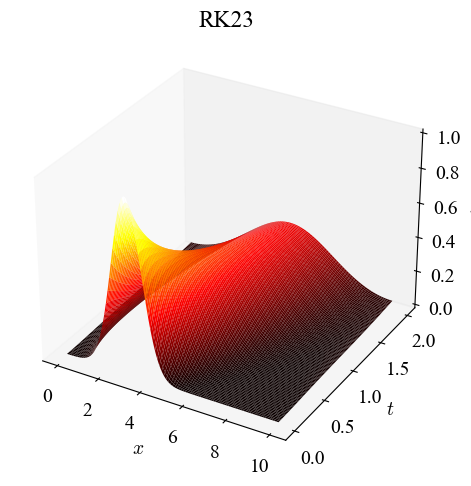

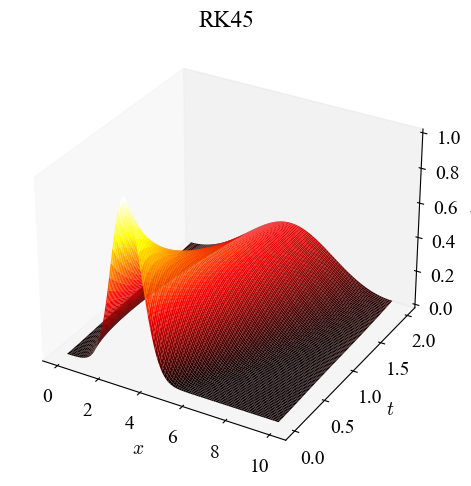

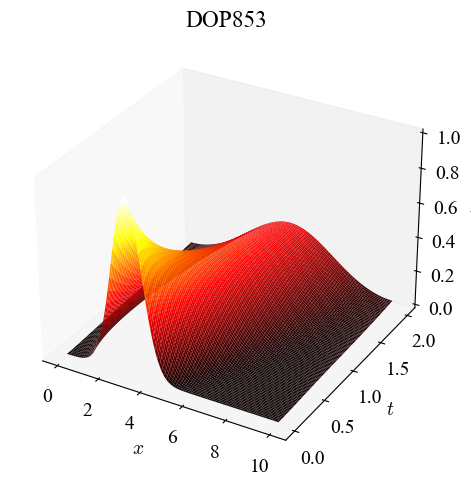

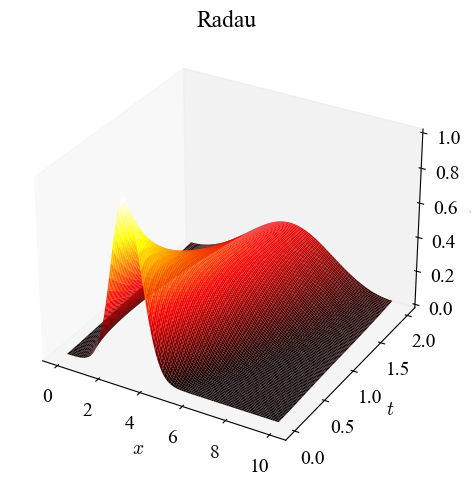

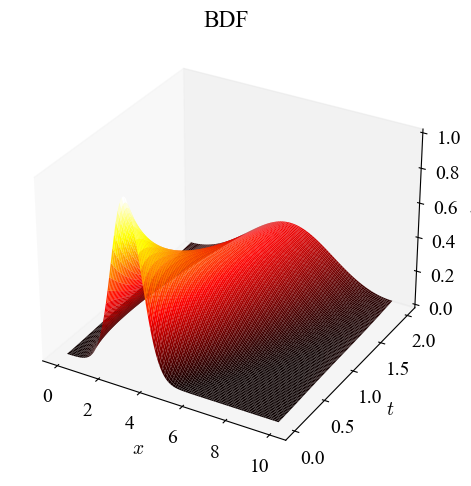

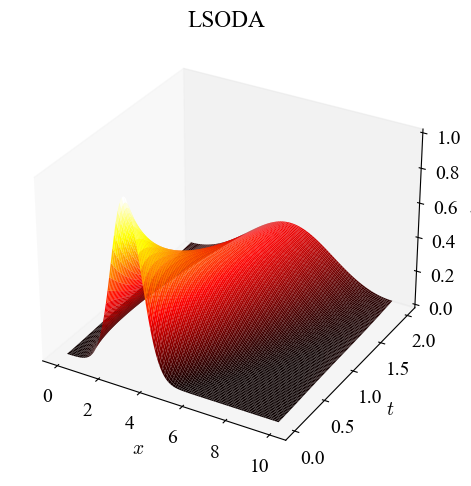

In [8]:
for method in methods:
    U = solutions[method].T
    fig = plt.figure(figsize=(5, 5))
    ax = fig.add_subplot(projection="3d")
    ax.plot_surface(X, T, U, cmap="hot", antialiased=True, rstride=5, cstride=5)
    ax.set_title(f"{method}")
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$t$")
    ax.set_zlabel(r"$u$")
    ax.grid(False)
    plt.tight_layout()
    plt.show()

## Boundary Value Problem

Consider the steady-state heat conduction equation on a unit square domain

$$
\nabla^2 T=\partial_x^2 T+\partial_y^2 T=0
$$

where $T(x,y)$ denotes the temperature field. The boundary conditions are

$$
T(x,0)=\sin(\pi x),\quad
T(x,1)=T(0,y)=T(1,y)=0.
$$

The computational grid is generated from the prime factorization of the target resolution. Each finer grid contains all points from the previous coarser grid, producing a nested refinement hierarchy.

In [9]:
def get_grid_sequence(N):
    i, factors = 2, []
    while i * i <= N:
        while N % i == 0:
            factors.append(i)
            N //= i
        i += 1
    if N > 1: factors.append(N)
    factors = sorted(factors, reverse=True)
    grids = [factors[0]]
    for factor in factors[1:]:
        grids.append(grids[-1] * factor)
    return np.array(grids) + 1

The steady-state heat conduction equation is discretized using a nine-point stencil. The update formula for an interior point is

$$
T_{ij}=\frac{4\sum{T_{axial}}+\sum{T_{diag}}}{20}
$$

where the axial neighbors are weighted four times more strongly than the diagonal neighbors. To improve convergence, the grid is divided into four independent color groups that are updated sequentially.

In [10]:
def red_black_gs(u, iterations=200):
    n = u.shape[0]
    for _ in range(iterations):
        for color in [0, 1]:
            mask = (np.arange(n)[:, None] + np.arange(n)) % 2 == color
            idx = mask[1:-1, 1:-1]
            u[1:-1, 1:-1][idx] = (u[0:-2, 1:-1] + u[2:, 1:-1] + u[1:-1, 0:-2] + u[1:-1, 2:])[idx] / 4
    return u

def gs_4_color(u, iterations=200):
    n = u.shape[0]
    for _ in range(iterations):
        for r_off, c_off in [(1, 1), (1, 2), (2, 1), (2, 2)]:
            axial = (u[r_off-1:n-2:2, c_off:n-1:2] +
                     u[r_off+1:n:2, c_off:n-1:2] +
                     u[r_off:n-1:2, c_off-1:n-2:2] +
                     u[r_off:n-1:2, c_off+1:n:2])
            diag = (u[r_off-1:n-2:2, c_off-1:n-2:2] +
                    u[r_off-1:n-2:2, c_off+1:n:2] +
                    u[r_off+1:n:2, c_off-1:n-2:2] +
                    u[r_off+1:n:2, c_off+1:n:2])
            u[r_off:n-1:2, c_off:n-1:2] = (4 * axial + diag) / 20
    return u

After convergence on a coarse grid, the solution is interpolated onto the next finer grid using `RegularGridInterpolator` with cubic interpolation. This provides an accurate initial guess and significantly reduces the number of iterations required on the finer grid.

In [11]:
N = 200
grids = get_grid_sequence(N)

u = np.zeros((grids[0], grids[0]))
u[0, :] = np.sin(np.pi * np.linspace(0, 1, grids[0]))
for i in range(1, grids[0] - 1):
    weightY = 1 - i / (grids[0] - 1)
    u[i, 1:-1] = weightY * u[0, 1:-1]
u = gs_4_color(u)

for n in grids[1:]:
    x = np.linspace(0, 1, n)
    u_new = np.zeros((n, n))
    u_new[0, :] = np.sin(np.pi * x)
    coords = np.linspace(0, 1, u.shape[0])
    interp = RegularGridInterpolator((coords, coords), u, method="cubic", bounds_error=False, fill_value=None)
    X, Y = np.meshgrid(x, x, indexing="ij")
    u_new = interp((X, Y))
    u_new[0, :] = np.sin(np.pi * x)         
    u = gs_4_color(u_new)

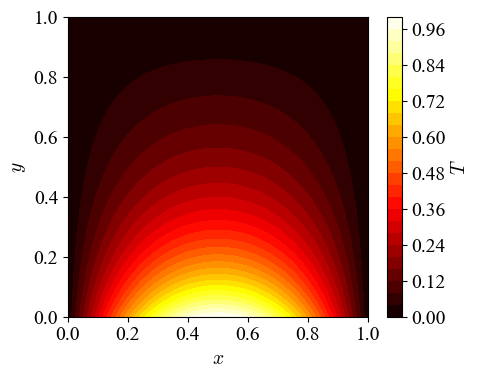

In [12]:
plt.figure(figsize=(5, 4))
plt.contourf(X, Y, u.T, 25, cmap="hot")
plt.colorbar(label=r"$T$")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.tight_layout()
plt.show()

The analytical solution satisfying the boundary conditions is

$$
T(x,y)=\sin(\pi x)\frac{\sinh(\pi(1-y))}{\sinh(\pi)}
$$

The numerical error is evaluated using the discrete $L_2$ norm.

In [13]:
u_analytical = np.sin(np.pi * X) * np.sinh(np.pi * (1 - Y)) / np.sinh(np.pi)
error = np.abs(u.T - u_analytical)
l2_error = np.sqrt(np.mean(error**2))
print(f"L2 Error: {l2_error:.3e}")

L2 Error: 1.290e-07


## Key Insights

* Finite-difference spatial discretization converts the advection–diffusion PDE into a system of ODEs that can be integrated with standard IVP solvers.
* Different time-integration methods produce consistent advection–diffusion solutions while exhibiting different numerical characteristics.
* Nested grid refinement transfers coarse-grid information to finer grids through cubic interpolation.
* The four-color Gauss–Seidel iteration accelerates convergence of the steady-state heat conduction solver.
* The numerical temperature distribution agrees closely with the analytical solution, yielding a small $L_2$ error.